# Pears trading

### Importing packages

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from hmmlearn import hmm

### Data

In [55]:
np.random.seed(42)
n_ticks = 2000

In [ ]:
B = np.cumsum(np.random.normal(0, 1, n_ticks)) + 100

# The Spread mean-reverts, but during shocks, cointegration breaks entirely!
spread = np.zeros(n_ticks)
for i in range(1, n_ticks):
    is_shock = (400 < i < 600) or (1400 < i < 1600)
    
    if is_shock:
        # REGIME 1 (Wild): Cointegration breaks. It becomes a random walk (phi = 1.0)
        # It no longer snaps back to zero. It just drifts.
        spread[i] = 1.0 * spread[i-1] + np.random.normal(0, 1.0)
    else:
        # REGIME 0 (Calm): Strong mean reversion (phi = 0.5)
        spread[i] = 0.5 * spread[i-1] + np.random.normal(0, 0.5)

# Asset A is just Asset B plus the spread
A = B + spread

print(f"A: {A}")
print(f"B: {B}")
print(f"spread: {spread}")

A: [100.49671415 100.02086071 100.69756666 ... 189.30726911 189.51475132
 190.01107107]
B: [100.49671415 100.35844985 101.00613839 ... 191.07626268 190.91319572
 190.16829307]
spread: [ 0.         -0.33758914 -0.30857173 ... -1.76899357 -1.3984444
 -0.157222  ]


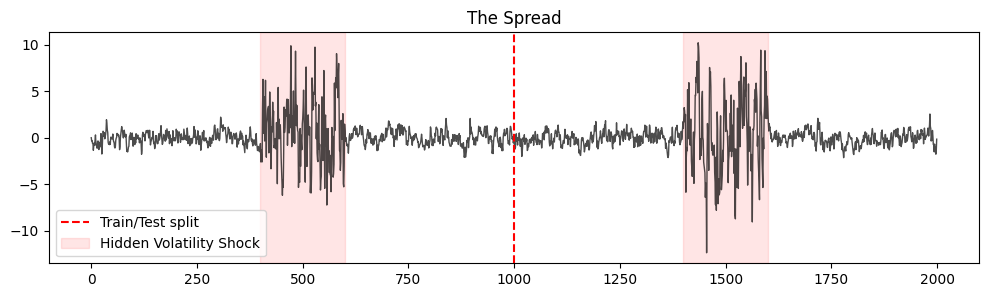

In [57]:
train_spread = spread[:1000]
test_spread = spread[1000:]

plt.figure(figsize=(12, 3))
plt.plot(spread, color='black', alpha=0.7, linewidth=1)
plt.axvline(1000, color='red', linestyle='--', label='Train/Test split')
plt.axvspan(400, 600, color='red', alpha=0.1, label='Hidden Volatility Shock')
plt.axvspan(1400, 1600, color='red', alpha=0.1)
plt.title("The Spread")
plt.legend()
plt.show()

### Training

In [58]:
ar_model = AutoReg(train_spread, lags=1, trend='n').fit()
ar_phi = ar_model.params[0]
print(f"AR(1) mean reversion spread: {ar_phi:.3f}")

X_train = train_spread.reshape(-1, 1)
hmm_model = hmm.GaussianHMM(n_components=2, covariance_type='full', random_state=42)
hmm_model.fit(X_train)

var_0 = hmm_model.covars_[0][0][0]
var_1 = hmm_model.covars_[1][0][0]
calm_state = 0 if var_0 < var_1 else 1
wild_state = 1 if calm_state == 0 else 0

print(f"HMM State {calm_state} Variance (Calm): {hmm_model.covars_[calm_state][0][0]:.3f}")
print(f"HMM State {wild_state} Variance (Wild): {hmm_model.covars_[wild_state][0][0]:.3f}")

AR(1) mean reversion spread: 0.585
HMM State 0 Variance (Calm): 0.473
HMM State 1 Variance (Wild): 12.383


### Backtesting

In [59]:
history = list(train_spread[-20:])
ar_predictions = []
regime_predictions = []

ar_trades_taken = 0
msar_trades_taken = 0

ar_pnl = [0]
msar_pnl = [0]
ar_trade_returns = [] 
msar_trade_returns = []

print("--- running out of sample backtest on 1000 ticks ---")

for t in range(len(test_spread) - 1):
    
    current_spread = test_spread[t]
    next_spread = test_spread[t+1]

    next_spread_pred = ar_phi * current_spread
    ar_predictions.append(next_spread_pred)

    X_live = np.array(history).reshape(-1, 1)
    current_regime = hmm_model.predict(X_live)[-1]
    regime_predictions.append(current_regime)

    trade_profit = -np.sign(current_spread) * (next_spread - current_spread) - 0.05
    
    step_ar_pnl = 0
    step_msar_pnl = 0

    # trading logic

    if abs(current_spread) > 1.0:
        ar_trades_taken += 1
        step_ar_pnl = trade_profit
        ar_trade_returns.append(trade_profit)

        if current_regime == calm_state:
            msar_trades_taken += 1
            step_msar_pnl = trade_profit
            msar_trade_returns.append(trade_profit)
            
    ar_pnl.append(step_ar_pnl)
    msar_pnl.append(step_msar_pnl)

    history.append(current_spread)
    history.pop(0)

print(f"Total Trade Signals Fired (Dumb AR Strategy): {ar_trades_taken}")
print(f"Total Trade Signals Fired (Smart MS-AR Strategy): {msar_trades_taken}")

--- running out of sample backtest on 1000 ticks ---
Total Trade Signals Fired (Dumb AR Strategy): 286
Total Trade Signals Fired (Smart MS-AR Strategy): 119


In [60]:
def calc_metrics(trade_returns):
    if not trade_returns: return {k: 0 for k in ['Trades', 'Win Rate', 'Total PnL', 'Avg Trade', 'Max Win', 'Max Loss', 'Profit Factor', 'Vol', 'Sharpe', 'Max DD']}
    
    tr = np.array(trade_returns)
    wins = tr[tr > 0]
    losses = tr[tr <= 0]
    
    # Cumulative PnL series for drawdown calculation
    cum_pnl = np.cumsum(tr)
    running_max = np.maximum.accumulate(cum_pnl)
    drawdowns = cum_pnl - running_max
    
    return {
        "Total Trades": len(tr),
        "Win Rate (%)": round((len(wins) / len(tr)) * 100, 2),
        "Total P&L": round(np.sum(tr), 2),
        "Avg Trade P&L": round(np.mean(tr), 3),
        "Largest Win": round(np.max(tr), 2) if len(wins) else 0,
        "Largest Loss": round(np.min(tr), 2) if len(losses) else 0,
        "Profit Factor": round(abs(np.sum(wins) / np.sum(losses)), 2) if np.sum(losses) != 0 else float('inf'),
        "Return Volatility": round(np.std(tr), 3),
        "Sharpe Ratio (Pseudo)": round(np.mean(tr) / np.std(tr) * np.sqrt(252), 2) if np.std(tr) != 0 else 0,
        "Max Drawdown": round(abs(np.min(drawdowns)), 2) if len(drawdowns) else 0
    }

In [61]:
ar_metrics = calc_metrics(ar_trade_returns)
msar_metrics = calc_metrics(msar_trade_returns)

metrics_df = pd.DataFrame([ar_metrics, msar_metrics], index=["Dumb AR", "Smart MS-AR"]).T
print("\n--- STRATEGY TEAR SHEET ---")
print(metrics_df)

cumulative_ar = np.cumsum(ar_pnl)
cumulative_msar = np.cumsum(msar_pnl)


--- STRATEGY TEAR SHEET ---
                       Dumb AR  Smart MS-AR
Total Trades           286.000      119.000
Win Rate (%)            68.880       73.950
Total P&L              243.950       37.420
Avg Trade P&L            0.853        0.314
Largest Win              9.810        1.330
Largest Loss            -7.310       -1.210
Profit Factor            2.750        4.510
Return Volatility        2.640        0.506
Sharpe Ratio (Pseudo)    5.130        9.860
Max Drawdown            10.080        1.210


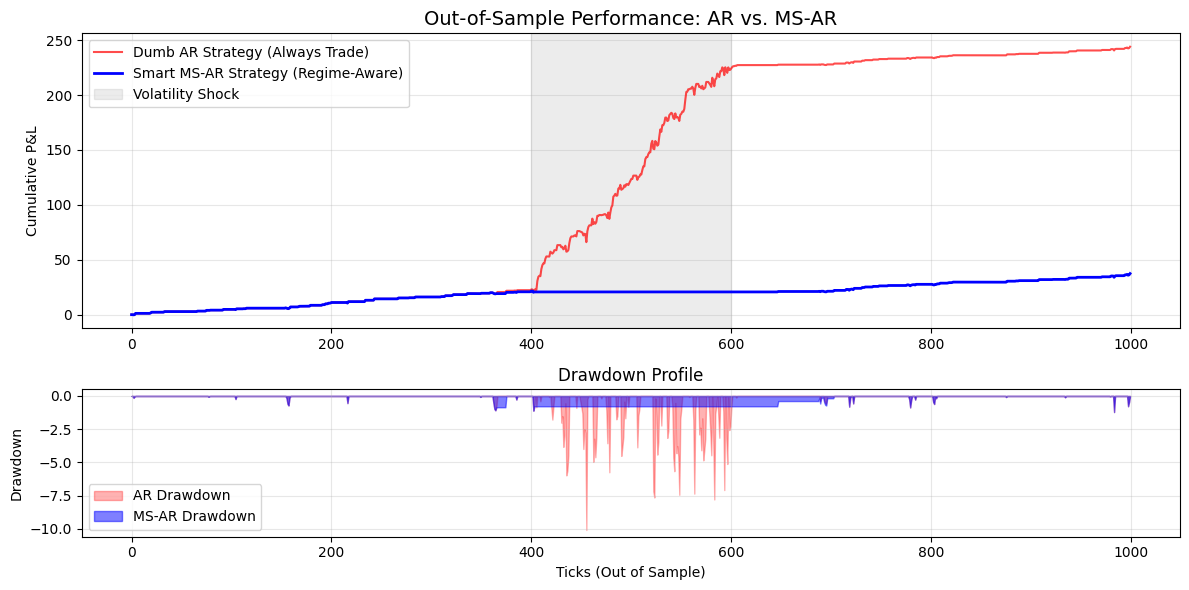

In [65]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [2, 1]})

# --- Subplot 1: Equity Curve ---
ax1.plot(cumulative_ar, label='Dumb AR Strategy (Always Trade)', color='red', alpha=0.7, linewidth=1.5)
ax1.plot(cumulative_msar, label='Smart MS-AR Strategy (Regime-Aware)', color='blue', linewidth=2)

# Highlight the shock zone (Ticks 1400-1600 in raw data = Ticks 400-600 in out-of-sample data)
ax1.axvspan(400, 600, color='grey', alpha=0.15, label='Volatility Shock')

ax1.set_title("Out-of-Sample Performance: AR vs. MS-AR", fontsize=14)
ax1.set_ylabel("Cumulative P&L")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Underwater Drawdown Curve ---
# Calculate rolling drawdowns
ar_running_max = np.maximum.accumulate(cumulative_ar)
ar_drawdown = cumulative_ar - ar_running_max

msar_running_max = np.maximum.accumulate(cumulative_msar)
msar_drawdown = cumulative_msar - msar_running_max

ax2.fill_between(range(len(ar_drawdown)), ar_drawdown, 0, color='red', alpha=0.3, label='AR Drawdown')
ax2.fill_between(range(len(msar_drawdown)), msar_drawdown, 0, color='blue', alpha=0.5, label='MS-AR Drawdown')

ax2.set_title("Drawdown Profile", fontsize=12)
ax2.set_xlabel("Ticks (Out of Sample)")
ax2.set_ylabel("Drawdown")
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()